# Clustering analysis

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from astroExplain.spectra.astronomy import BPT, get_subclass_summary
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

In [2]:
def map_to_dict(df, name, color, offsets):
    """
    Helper function to map a DataFrame to the expected dictionary format for plotting.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    name (str): The name of the dataset.
    color (str): The color to use for plotting.
    offsets (list of tuple): The offsets for the annotations.

    Returns:
    dict: A dictionary containing the mapped data.
    """
    return {
        "name": name,
        "color": color,
        "cluster_id": df["cluster_id"].values,
        "offsets": offsets or {},
        "n2_ha_med": df["n2_ha_med"].values,
        "n2_ha_p45": df["n2_ha_p45"].values,
        "n2_ha_p55": df["n2_ha_p55"].values,
        "o3_hb_med": df["o3_hb_med"].values,
        "o3_hb_p45": df["o3_hb_p45"].values,
        "o3_hb_p55": df["o3_hb_p55"].values,
    }

# Config

## Directories

In [3]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_6_dir = f"{thesis_dir}/chapters/06_figures"

clusters_meta_dirs_dict = {
    'se': f'{clustering_dir}/bin_03/mse/metadata.csv.gz',
    'iforest': f'{clustering_dir}/bin_03/iforest/metadata.csv.gz',
    'lof': f'{clustering_dir}/bin_03/lof/metadata.csv.gz'
}

## Data

In [4]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)
se_df = pd.read_csv(clusters_meta_dirs_dict['se'], index_col="specobjid")
iforest_df = pd.read_csv(
    clusters_meta_dirs_dict['iforest'], index_col="specobjid"
)
lof_df = pd.read_csv(clusters_meta_dirs_dict['lof'], index_col="specobjid")

# Cluster ratios

In [5]:
# get SE clusters 0, 1, 2, 3 and 4
se_ratios_df = BPT.median_45_55_ratios(se_df)
se_cluster_mask = se_ratios_df["cluster_id"].isin([0, 1, 2, 3, 4])
se_ratios_df = se_ratios_df[se_cluster_mask]

# get iforest clusters 0, 1, 2 and 3
iforest_ratios_df = BPT.median_45_55_ratios(iforest_df)
iforest_cluster_mask = iforest_ratios_df["cluster_id"].isin([0, 1, 2, 3])
iforest_ratios_df = iforest_ratios_df[iforest_cluster_mask]

# get lof clusters 0, 2, 3
lof_ratios_df = BPT.median_45_55_ratios(lof_df)
lof_cluster_mask = lof_ratios_df["cluster_id"].isin([0, 2, 3])
lof_ratios_df = lof_ratios_df[lof_cluster_mask]

# BPT diagrams

## SE BPT

In [6]:
# # BPT of spectra in single cluster
# cluster_id = 0
# mask = cluster_meta_df["cluster"] == cluster_id

# metadata_df = cluster_meta_df.loc[mask]
# n_anomalies_in_cluster = metadata_df.shape[0]
# labels = ["" for i in range(0, n_anomalies_in_cluster)]
# n2_ha = metadata_df["nii_to_halpha"].to_list()
# o3_hb = metadata_df["oiii_to_hbeta"].to_list()
# log_n2_ha = np.log10(n2_ha)
# log_o3_hb = np.log10(o3_hb)

# fig, ax = plt.subplots(figsize=(10, 8))
# fig, ax = BPT.standar_bpt_plot(fig, ax, log_n2_ha, log_o3_hb, labels, xytext=(-5, 5))

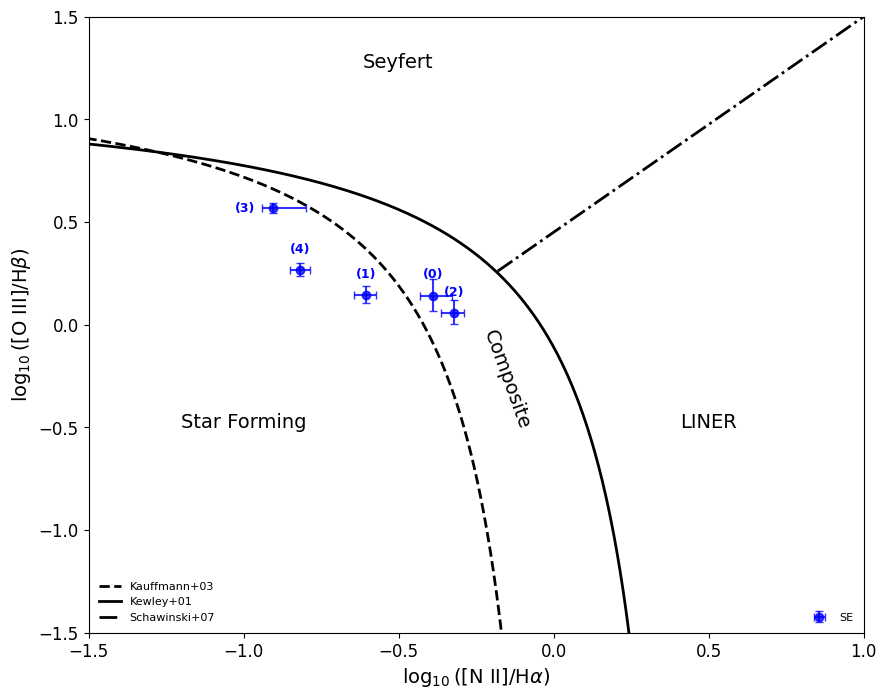

In [6]:
se_offsets = {
    0: (0, 15),
    1: (0, 15),
    2: (0, 15),
    3: (-20, 0),
    4: (0, 15),
}
datasets = [map_to_dict(se_ratios_df, "SE", "blue", se_offsets)]
fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = BPT.multi_dataset_bpt_plot(fig, ax, datasets, xytext=(-5, 5))
plt.show()
# # save fig
# fname = 'bpt_se_clusters'
# fig.savefig(f"{ch_6_dir}/{fname}.pdf", bbox_inches="tight")

## Latent BPT

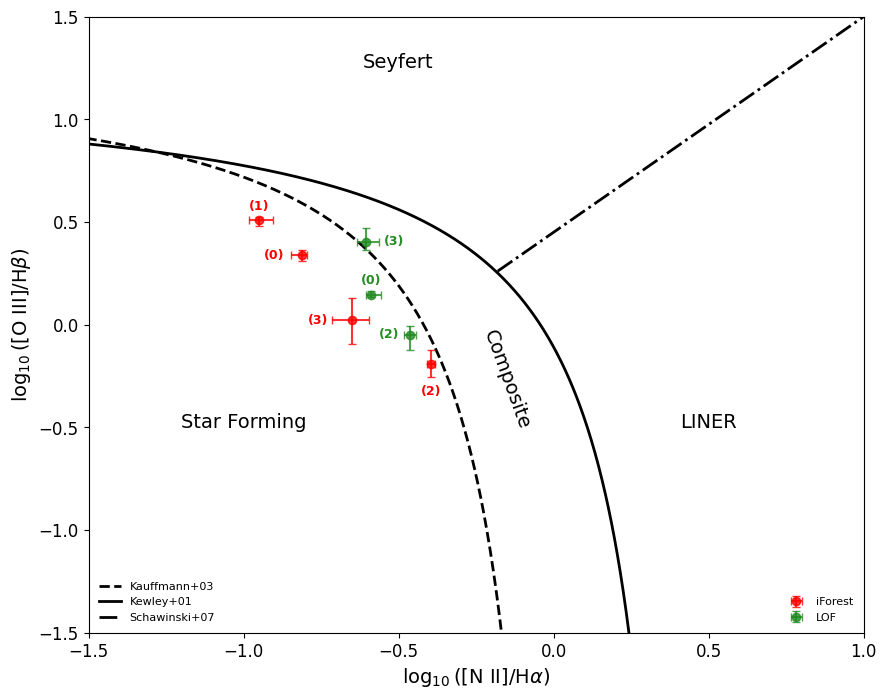

In [8]:
iforest_offsets = {
    0: (-20, 0),
    1: (0, 10),
    2: (0, -20),
    3: (-25, 0),
}
lof_offsets = {
    0: (0, 10),
    2: (-15, 0),
    3: (20, 0),
}
datasets = [
    map_to_dict(iforest_ratios_df, "iForest", "red", iforest_offsets),
    map_to_dict(lof_ratios_df, "LOF", "forestgreen", lof_offsets)
]

fig, ax = plt.subplots(figsize=(10, 8))
fig, ax = BPT.multi_dataset_bpt_plot(fig, ax, datasets, xytext=(-5, 5))
plt.show()

# # save fig
# fname = 'bpt_latent_clusters'
# fig.savefig(f"{ch_6_dir}/{fname}.pdf", bbox_inches="tight")

## SE & Latent

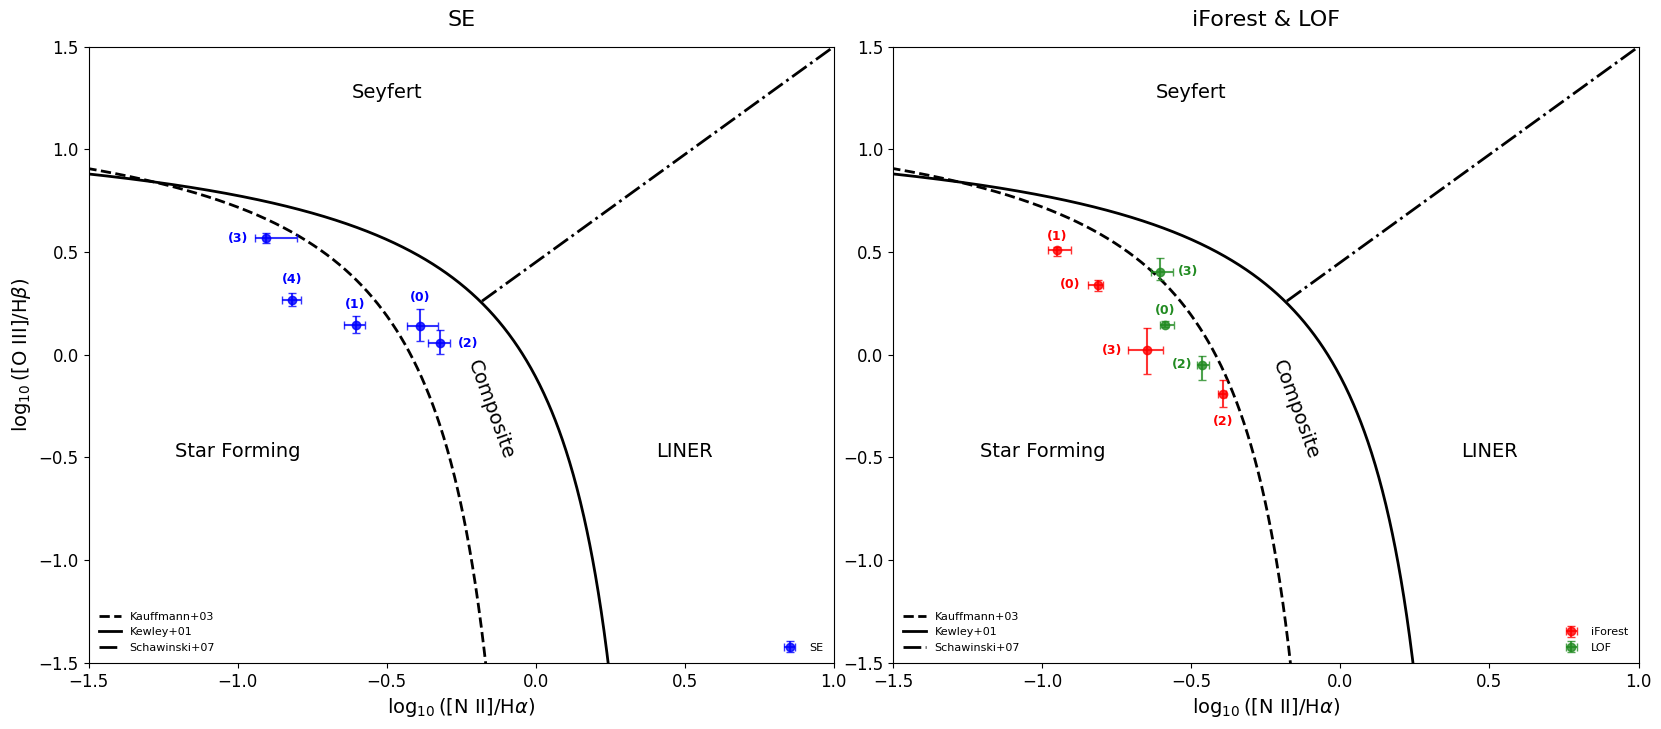

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8), sharey=False)

# -------------------------------------------------------------
# Left Plot: SE Clusters
# -------------------------------------------------------------
se_offsets = {
    0: (0, 20),
    1: (0, 15),
    2: (20, 0),
    3: (-20, 0),
    4: (0, 15),
}
se_datasets = [map_to_dict(se_ratios_df, "SE", "blue", se_offsets)]

# Pass axes[0] to plot on the left side
BPT.multi_dataset_bpt_plot(fig, axes[0], se_datasets, xytext=(-5, 5))
axes[0].set_title("SE", fontsize=16, pad=15)

# -------------------------------------------------------------
# Right Plot: Latent Clusters (iForest & LOF)
# -------------------------------------------------------------
iforest_offsets = {
    0: (-20, 0),
    1: (0, 10),
    2: (0, -20),
    3: (-25, 0),
}
lof_offsets = {
    0: (0, 10),
    1: (0, 15),
    2: (-15, 0),
    3: (20, 0),
}
latent_datasets = [
    map_to_dict(iforest_ratios_df, "iForest", "red", iforest_offsets),
    map_to_dict(lof_ratios_df, "LOF", "forestgreen", lof_offsets)
]

# Pass axes[1] to plot on the right side
BPT.multi_dataset_bpt_plot(fig, axes[1], latent_datasets, xytext=(-5, 5))
axes[1].set_title("iForest & LOF", fontsize=16, pad=15)

# -------------------------------------------------------------
# Final Formatting
# -------------------------------------------------------------
# Ensures the labels and titles do not overlap between the two columns
# plt.tight_layout()
axes[1].set_ylabel("")
plt.subplots_adjust(hspace=0.06, wspace=0.08)
plt.show()
# # save fig
# fname = 'bpt_clustering'
# fig.savefig(f"{ch_6_dir}/{fname}.pdf", bbox_inches="tight")

# SDSS class

In [10]:
# Define target row order and mapping
subclass_order = [
    "STARFORMING",
    "STARBURST",
    "STARFORMING BROADLINE",
    "STARBURST BROADLINE",
    "AGN",
    "AGN BROADLINE",
    "BROADLINE",
    "UNDEFINED",
    "Total",
]

## SE

In [11]:
cluster_meta_df = se_df.copy()
cluster_dfs = {}
clusters = [0, 1, 2, 3, 4, 5]

for c_id in clusters:

    cluster_mask = cluster_meta_df["cluster"] == c_id
    metadata_df = cluster_meta_df.loc[cluster_mask]
    df_c = get_subclass_summary(metadata_df)

    # 1. Map 'nan' string / NaN values to 'UNDEFINED'
    df_c["subClass"] = df_c["subClass"].replace({"nan": "UNDEFINED", None: "UNDEFINED"})

    # 2. Set 'subClass' as index to align across clusters
    df_c = df_c.set_index("subClass")

    # 3. Ensure all categories are present, filling missing with 0
    df_c = df_c.reindex(subclass_order).fillna(0)

    # Recompute Total row to ensure accurate sums
    df_c.loc["Total", "count"] = df_c.drop("Total")["count"].sum()
    df_c.loc["Total", "pct"] = df_c.drop("Total")["pct"].sum()

    # Format counts as integers
    df_c["count"] = df_c["count"].astype(int)

    cluster_dfs[f"Cluster {c_id}"] = df_c

# 4. Concatenate with MultiIndex columns (Cluster level on top)
combined_df = pd.concat(cluster_dfs, axis=1)
combined_df = combined_df.reset_index()
new_columns = [("", "subClass")] + combined_df.columns.tolist()[1:]
combined_df.columns = pd.MultiIndex.from_tuples(new_columns)

combined_df.to_clipboard(excel=True, index=False)
combined_df

Cluster 0           Cluster 1           Cluster 2  \
                subClass     count       pct     count       pct     count   
0            STARFORMING       110  0.269608        22  0.040741        29   
1              STARBURST        81  0.198529       485  0.898148       166   
2  STARFORMING BROADLINE         0  0.000000         2  0.003704         3   
3    STARBURST BROADLINE         0  0.000000         6  0.011111         3   
4                    AGN        55  0.134804        13  0.024074        58   
5          AGN BROADLINE        17  0.041667         0  0.000000        11   
6              BROADLINE        10  0.024510         0  0.000000         4   
7              UNDEFINED       135  0.330882        12  0.022222        14   
8                  Total       408  1.000000       540  1.000000       288   

            Cluster 3           Cluster 4           Cluster 5            
        pct     count       pct     count       pct     count       pct  
0  0.100694        13  0.048507        54  0.177632         2  0.181818  
1  0.576389       171  0.638060       240  0.789474         1  0.090909  
2  0.010417         0  0.000000         0  0.000000         0  0.000000  
3  0.010417         0  0.000000         0  0.000000         0  0.000000  
4  0.201389        70  0.261194         2  0.006579         0  0.000000  
5  0.038194        11  0.041045         0  0.000000         0  0.000000  
6  0.013889         0  0.000000         0  0.000000         1  0.090909  
7  0.048611         3  0.011194         8  0.026316         7  0.636364  
8  1.000000       268  1.000000       304  1.000000        11  1.000000

## iForest

In [12]:
cluster_meta_df = iforest_df.copy()
cluster_dfs = {}
clusters = [0, 1, 2, 3, 4]

for c_id in clusters:

    cluster_mask = cluster_meta_df["cluster"] == c_id
    metadata_df = cluster_meta_df.loc[cluster_mask]
    df_c = get_subclass_summary(metadata_df)

    # 1. Map 'nan' string / NaN values to 'UNDEFINED'
    df_c["subClass"] = df_c["subClass"].replace({"nan": "UNDEFINED", None: "UNDEFINED"})

    # 2. Set 'subClass' as index to align across clusters
    df_c = df_c.set_index("subClass")

    # 3. Ensure all categories are present, filling missing with 0
    df_c = df_c.reindex(subclass_order).fillna(0)

    # Recompute Total row to ensure accurate sums
    df_c.loc["Total", "count"] = df_c.drop("Total")["count"].sum()
    df_c.loc["Total", "pct"] = df_c.drop("Total")["pct"].sum()

    # Format counts as integers
    df_c["count"] = df_c["count"].astype(int)

    cluster_dfs[f"Cluster {c_id}"] = df_c

# 4. Concatenate with MultiIndex columns (Cluster level on top)
combined_df = pd.concat(cluster_dfs, axis=1)
combined_df = combined_df.reset_index()
new_columns = [("", "subClass")] + combined_df.columns.tolist()[1:]
combined_df.columns = pd.MultiIndex.from_tuples(new_columns)

combined_df.to_clipboard(excel=True, index=False)
combined_df

Cluster 0           Cluster 1           Cluster 2  \
                subClass     count       pct     count       pct     count   
0            STARFORMING         5  0.014327         1  0.002016         5   
1              STARBURST       331  0.948424       391  0.788306       452   
2  STARFORMING BROADLINE         1  0.002865         0  0.000000         0   
3    STARBURST BROADLINE         1  0.002865         0  0.000000         1   
4                    AGN         6  0.017192        90  0.181452        12   
5          AGN BROADLINE         3  0.008596         8  0.016129         3   
6              BROADLINE         0  0.000000         0  0.000000         0   
7              UNDEFINED         2  0.005731         6  0.012097         1   
8                  Total       349  1.000000       496  1.000000       474   

            Cluster 3           Cluster 4            
        pct     count       pct     count       pct  
0  0.010549         3  0.012048        15  0.059761  
1  0.953586       243  0.975904        44  0.175299  
2  0.000000         0  0.000000         0  0.000000  
3  0.002110         0  0.000000         0  0.000000  
4  0.025316         2  0.008032         1  0.003984  
5  0.006329         0  0.000000         1  0.003984  
6  0.000000         0  0.000000         4  0.015936  
7  0.002110         1  0.004016       186  0.741036  
8  1.000000       249  1.000000       251  1.000000

## LOF

In [13]:
cluster_meta_df = lof_df.copy()
cluster_dfs = {}
clusters = [0, 1, 2, 3, 4]

for c_id in clusters:

    cluster_mask = cluster_meta_df["cluster"] == c_id
    metadata_df = cluster_meta_df.loc[cluster_mask]
    df_c = get_subclass_summary(metadata_df)

    # 1. Map 'nan' string / NaN values to 'UNDEFINED'
    df_c["subClass"] = df_c["subClass"].replace({"nan": "UNDEFINED", None: "UNDEFINED"})

    # 2. Set 'subClass' as index to align across clusters
    df_c = df_c.set_index("subClass")

    # 3. Ensure all categories are present, filling missing with 0
    df_c = df_c.reindex(subclass_order).fillna(0)

    # Recompute Total row to ensure accurate sums
    df_c.loc["Total", "count"] = df_c.drop("Total")["count"].sum()
    df_c.loc["Total", "pct"] = df_c.drop("Total")["pct"].sum()

    # Format counts as integers
    df_c["count"] = df_c["count"].astype(int)

    cluster_dfs[f"Cluster {c_id}"] = df_c

# 4. Concatenate with MultiIndex columns (Cluster level on top)
combined_df = pd.concat(cluster_dfs, axis=1)
combined_df = combined_df.reset_index()
new_columns = [("", "subClass")] + combined_df.columns.tolist()[1:]
combined_df.columns = pd.MultiIndex.from_tuples(new_columns)

combined_df.to_clipboard(excel=True, index=False)
combined_df

Cluster 0           Cluster 1           Cluster 2  \
                subClass     count       pct     count       pct     count   
0            STARFORMING        26  0.145251       111  0.151020        33   
1              STARBURST       126  0.703911        38  0.051701       168   
2  STARFORMING BROADLINE         4  0.022346         2  0.002721         1   
3    STARBURST BROADLINE         3  0.016760         0  0.000000         3   
4                    AGN         5  0.027933        30  0.040816        21   
5          AGN BROADLINE         6  0.033520        15  0.020408        10   
6              BROADLINE         0  0.000000        16  0.021769         2   
7              UNDEFINED         9  0.050279       523  0.711565         1   
8                  Total       179  1.000000       735  1.000000       239   

            Cluster 3           Cluster 4            
        pct     count       pct     count       pct  
0  0.138075        14  0.091503        42  0.081871  
1  0.702929       105  0.686275         8  0.015595  
2  0.004184         0  0.000000         3  0.005848  
3  0.012552         0  0.000000         0  0.000000  
4  0.087866        29  0.189542         9  0.017544  
5  0.041841         2  0.013072         3  0.005848  
6  0.008368         1  0.006536        20  0.038986  
7  0.004184         2  0.013072       428  0.834308  
8  1.000000       153  1.000000       513  1.000000

# Redshift

In [14]:
# low_wave, upper_wave = 5_565, 5_590
# z_df["lower_wave_min"] = low_wave / (1 + z_df["min"])
# z_df["upper_wave_min"] = upper_wave / (1 + z_df["min"])
# z_df["lower_wave_max"] = low_wave / (1 + z_df["max"])
# z_df["upper_wave_max"] = upper_wave / (1 + z_df["max"])
# z_df["lower_wave_mean"] = low_wave / (1 + z_df["mean"])
# z_df["upper_wave_mean"] = upper_wave / (1 + z_df["mean"])
# z_df["lower_wave_median"] = low_wave / (1 + z_df["median"])
# z_df["upper_wave_median"] = upper_wave / (1 + z_df["median"])
# z_df

## SE

In [15]:
z_se_df = se_df.groupby("cluster")["z"].agg(
    min="min",
    max="max",
    mean="mean",
    p45=lambda x: x.quantile(0.45),
    median="median",
    p55=lambda x: x.quantile(0.55)
).reset_index()
z_se_df.to_clipboard(excel=True, index=False)
z_se_df

,cluster,min,max,mean,p45,median,p55
0,0,0.010673,0.262315,0.090362,0.083784,0.089639,0.106530
1,1,0.010093,0.261698,0.068517,0.049156,0.055840,0.064719
2,2,0.011134,0.271920,0.083456,0.066880,0.075833,0.084468
3,3,0.010262,0.234167,0.053717,0.031455,0.035546,0.042456
4,4,0.011578,0.179591,0.042405,0.025413,0.027792,0.029903
5,5,0.067039,0.089808,0.085675,0.088293,0.088545,0.088617


## iForest

In [16]:
z_iforest_df = iforest_df.groupby("cluster")["z"].agg(
    min="min",
    max="max",
    mean="mean",
    p45=lambda x: x.quantile(0.45),
    median="median",
    p55=lambda x: x.quantile(0.55)
).reset_index()
z_iforest_df.to_clipboard(excel=True, index=False)
z_iforest_df

,cluster,min,max,mean,p45,median,p55
0,0,0.017820,0.215538,0.056854,0.038879,0.042472,0.047152
1,1,0.010132,0.234753,0.049638,0.033539,0.037429,0.041851
2,2,0.010093,0.263567,0.067417,0.048115,0.055322,0.061262
3,3,0.010714,0.127874,0.027679,0.019099,0.020140,0.021366
4,4,0.010838,0.245802,0.075763,0.063265,0.068400,0.076261


## LOF

In [17]:
z_lof_df = lof_df.groupby("cluster")["z"].agg(
    min="min",
    max="max",
    mean="mean",
    p45=lambda x: x.quantile(0.45),
    median="median",
    p55=lambda x: x.quantile(0.55)
).reset_index()
z_lof_df.to_clipboard(excel=True, index=False)
z_lof_df

,cluster,min,max,mean,p45,median,p55
0,0,0.022368,0.215538,0.076910,0.066560,0.071867,0.077398
1,1,0.011012,0.290295,0.081899,0.072419,0.077307,0.080888
2,2,0.010398,0.263567,0.057608,0.034461,0.040940,0.048051
3,3,0.010551,0.240697,0.059394,0.033755,0.037146,0.046366
4,4,0.010200,0.219666,0.088013,0.078721,0.083364,0.087896


# Signal to Noise

## SE

In [18]:
snr_se_df = se_df.groupby("cluster")["snMedian"].agg(
    min="min",
    max="max",
    mean="mean",
    p45=lambda x: x.quantile(0.45),
    median="median",
    p55=lambda x: x.quantile(0.55)
).reset_index()
snr_se_df.to_clipboard(excel=True, index=False)
snr_se_df

,cluster,min,max,mean,p45,median,p55
0,0,17.55957,48.30596,21.636292,19.845672,20.19309,20.657554
1,1,17.54445,67.50546,22.260594,19.986997,20.41569,20.939511
2,2,17.54430,48.24164,22.864000,20.525890,21.01839,21.791926
3,3,17.54821,53.69836,22.765036,20.246597,20.67884,21.356732
4,4,17.55193,46.90273,21.406915,19.777033,19.96242,20.466079
5,5,17.54917,29.66963,21.033115,20.023330,20.12040,20.277460


## iForest

In [19]:
snr_iforest_df = iforest_df.groupby("cluster")["snMedian"].agg(
    min="min",
    max="max",
    mean="mean",
    p45=lambda x: x.quantile(0.45),
    median="median",
    p55=lambda x: x.quantile(0.55)
).reset_index()
snr_iforest_df.to_clipboard(excel=True, index=False)
snr_iforest_df

,cluster,min,max,mean,p45,median,p55
0,0,17.54382,41.84349,22.422206,20.331570,20.853140,21.445728
1,1,17.54821,53.69836,22.884385,20.450413,20.920615,21.493915
2,2,17.54430,53.22192,25.311001,22.430299,23.112045,24.162251
3,3,17.56347,65.29255,25.374883,22.471462,23.359570,24.107112
4,4,17.54807,62.60099,24.070136,21.110930,21.529400,22.516565


## LOF

In [20]:
snr_lof_df = lof_df.groupby("cluster")["snMedian"].agg(
    min="min",
    max="max",
    mean="mean",
    p45=lambda x: x.quantile(0.45),
    median="median",
    p55=lambda x: x.quantile(0.55)
).reset_index()
snr_lof_df.to_clipboard(excel=True, index=False)
snr_lof_df

,cluster,min,max,mean,p45,median,p55
0,0,17.55193,49.69391,22.784256,20.323321,20.84076,21.709039
1,1,17.54605,62.60099,24.989542,22.249834,22.92120,23.539198
2,2,17.54821,53.79778,24.942087,21.996744,22.39543,23.405712
3,3,17.57890,50.26729,24.123105,21.053114,22.11615,22.862864
4,4,17.57984,59.43739,24.265379,21.418850,22.20928,23.180562
